# Naver Menu들에서 '매일' 텍스트를 추출

In [1]:
import requests as req
from bs4 import BeautifulSoup as bs

'\n<!doctype html>                          <html lang="ko" data-dark="false"> <head> <meta charset="utf-8"> <title>NAVER</title> <meta http-equiv="X-UA-Compatible" content="IE=edge"> <meta name="viewport" content="width=1190"> <meta name="apple-mobile-web-app-title" content="NAVER"/> <meta name="robots" content="index,nofollow"/> <meta name="description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta property="og:title" content="네이버"> <meta property="og:url" content="https://www.naver.com/"> <meta property="og:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta property="og:description" content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요"/> <meta name="twitter:card" content="summary"> <meta name="twitter:title" content=""> <meta name="twitter:url" content="https://www.naver.com/"> <meta name="twitter:image" content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png"> <meta name="twitter:description" content="네이버
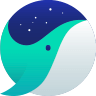
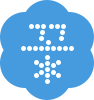

In [3]:
# request 브라우저를 사용자가 켜는 것과 같다.

res = req.get('https://www.naver.com')
res.text

### BeautifulSoup으로 객체화를 진행해줘야함

<!DOCTYPE html>
<html data-dark="false" lang="ko"> <head> <meta charset="utf-8"/> <title>NAVER</title> <meta content="IE=edge" http-equiv="X-UA-Compatible"/> <meta content="width=1190" name="viewport"/> <meta content="NAVER" name="apple-mobile-web-app-title"/> <meta content="index,nofollow" name="robots"/> <meta content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요" name="description"/> <meta content="네이버" property="og:title"/> <meta content="https://www.naver.com/" property="og:url"/> <meta content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png" property="og:image"/> <meta content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요" property="og:description"/> <meta content="summary" name="twitter:card"/> <meta content="" name="twitter:title"/> <meta content="https://www.naver.com/" name="twitter:url"/> <meta content="https://s.pstatic.net/static/www/mobile/edit/2016/0705/mobile_212852414260.png" name="twitter:image"/> <meta content="네이버 메인에서 다양한 정보와 유용한 컨텐츠를 만나 보세요" name="twitter:
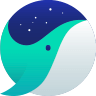
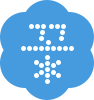

In [4]:
soup = bs(res.text,'lxml')
soup

### f12 개발자 모드로 요소들을 확인해보기 

#### CSS Selector는 어떤것이 있을까?
1. tag selector('태그이름') -> google.youtube 실습 때 사용
2. id selector(#)
3. class selector(.) -> 네이버 메일 실습 때 사용
3. child selector(>)
5. parent selector(&)
6. adjacent selector(+)
7. General Sibling(일반형제) selector (~)

In [6]:
# 그럼 이제 메뉴들을 뽑아야함
    # 메뉴들? -> select
    # 우리에겐 a란 tag 이름과, nav란 class 이름이 주어졌다.

naver_menus = soup.select('a.nav')
naver_menus

[<a class="nav" data-clk="svc.mail" href="https://mail.naver.com/"><i class="ico_mail"></i>메일</a>,
 <a class="nav" data-clk="svc.cafe" href="https://section.cafe.naver.com/">카페</a>,
 <a class="nav" data-clk="svc.blog" href="https://section.blog.naver.com/">블로그</a>,
 <a class="nav" data-clk="svc.kin" href="https://kin.naver.com/">지식iN</a>,
 <a class="nav shop" data-clk="svc.shopping" href="https://shopping.naver.com/"><span class="blind">쇼핑</span></a>,
 <a class="nav shoplive" data-clk="svc.shoppinglive" href="https://shoppinglive.naver.com/home"><span class="blind">쇼핑LIVE</span></a>,
 <a class="nav" data-clk="svc.pay" href="https://order.pay.naver.com/home">Pay</a>,
 <a class="nav" data-clk="svc.tvcast" href="https://tv.naver.com/"><i class="ico_tv"></i>TV</a>,
 <a class="nav" data-clk="svc.dic" href="https://dict.naver.com/">사전</a>,
 <a class="nav" data-clk="svc.news" href="https://news.naver.com/">뉴스</a>,
 <a class="nav" data-clk="svc.stock" href="https://finance.naver.com/">증권</a>,


In [10]:
# 인덱싱으로 '메일'요소 뽑기.
    # 텍스트 데이터로 변환

naver_menu_mail = soup.select('a.nav')[0].text
naver_menu_mail

'메일'

In [8]:
# for loop으로 추출을 해보자.
# 총 메뉴가 몇개나 뽑혔는지, len함수로 뽑아보자
len(naver_menus)

16

In [9]:
# for loop

for i in range(len(naver_menus)):
    print(naver_menus[i].text)

메일
카페
블로그
지식iN
쇼핑
쇼핑LIVE
Pay
TV
사전
뉴스
증권
부동산
지도
VIBE
도서
웹툰


In [11]:
# for loop으로 메뉴들을 추출했어요
    # 메일을 어떻게 인덱싱을 해줄까?
naver_menus[0].text

'메일'

# NAVER 날씨에서 온도 데이터 수집

In [12]:
res_weather = req.get('https://search.naver.com/search.naver?where=nexearch&sm=top_hty&fbm=1&ie=utf8&query=%EC%98%A4%EB%8A%98%EC%9D%98+%EB%82%A0%EC%94%A8')
res_weather

<Response [200]>

In [13]:
# beautifulsoup을 사용하기 위해 객체화 진행 
soup = bs(res_weather.text,'lxml')
soup

<!DOCTYPE html>
<html lang="ko"><head> <meta charset="utf-8"/> <meta content="always" name="referrer"/> <meta content="telephone=no,address=no,email=no" name="format-detection"/> <meta content="width=device-width,initial-scale=1.0,maximum-scale=2.0" name="viewport"/> <meta content="오늘의 날씨 : 네이버 통합검색" property="og:title"/> <meta content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png" property="og:image"/> <meta content="'오늘의 날씨'의 네이버 통합검색 결과입니다." property="og:description"/> <meta content="'오늘의 날씨'의 네이버 통합검색 결과입니다." lang="ko" name="description"/> <title>오늘의 날씨 : 네이버 통합검색</title> <link href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_191118_pc.ico" rel="shortcut icon"/> <link href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" rel="search" title="Naver" type="application/opensearchdescription+xml"/><link href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_230427.css" rel="stylesheet" type="text/css"/> <link href="https://ssl.pstatic

In [15]:
temperature = soup.select('div.temperature_text > strong')
temperature[0].text

'현재 온도17.4°'

In [16]:
# 원하는 데이터가 하나?
    # 그러면 select_one을 사용해도 무방
temperature = soup.select_one('div.temperature_text > strong')
temperature.text

'현재 온도17.4°'

# NAVER NEWS 기사제목 가져오기

In [17]:
# 기억해주셔야 할 부분
    # 우리는 같은 네이버 서비스를 이용하고 있지만, 컴퓨터는 모릅니다.
    # NAVER NEWS page를 새로 요청 (res, 다시 객체화)
    # select, 혹은 select_one 함수로 태그의 위치를 지정
    # 출력

In [18]:
# https://search.naver.com/search.naver?where=news&sm=tab_jum&query=%EB%9F%AC%EC%8B%9C%EC%95%84+%EC%9A%B0%ED%81%AC%EB%9D%BC%EC%9D%B4%EB%82%98+%EC%A0%84%EC%9F%81

# 1. 요청 / 응답받기
url = 'https://search.naver.com/search.naver?where=news&sm=tab_jum&query=%EB%9F%AC%EC%8B%9C%EC%95%84+%EC%9A%B0%ED%81%AC%EB%9D%BC%EC%9D%B4%EB%82%98+%EC%A0%84%EC%9F%81'
res_news = req.get(url)
res_news

<Response [200]>

In [19]:
# 2. beautifulsoup 객체화 진행
soup_news = bs(res_news.text, 'lxml')
soup_news

<!DOCTYPE html>
<html lang="ko"><head> <meta charset="utf-8"/> <meta content="always" name="referrer"/> <meta content="telephone=no,address=no,email=no" name="format-detection"/> <meta content="width=device-width,initial-scale=1.0,maximum-scale=2.0" name="viewport"/> <meta content="러시아 우크라이나 전쟁 : 네이버 뉴스검색" property="og:title"/> <meta content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png" property="og:image"/> <meta content="'러시아 우크라이나 전쟁'의 네이버 뉴스검색 결과입니다." property="og:description"/> <meta content="'러시아 우크라이나 전쟁'의 네이버 뉴스검색 결과입니다." lang="ko" name="description"/> <title>러시아 우크라이나 전쟁 : 네이버 뉴스검색</title> <link href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_191118_pc.ico" rel="shortcut icon"/> <link href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" rel="search" title="Naver" type="application/opensearchdescription+xml"/><link href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_230427.css" rel="stylesheet" type="text/css"/> <link h

In [21]:
article = soup_news.select_one('a.news_tit')
article.text

'KT, 러시아 IDC 법인 1년만에 철수… 우크라이나 전쟁 여파'

# 기사'들'을 뽑아오기
- select 함수로 
- for 문 (for loop)을 이용해서 추출

In [25]:
articles = soup_news.select('a.news_tit')
articles[0].text

'KT, 러시아 IDC 법인 1년만에 철수… 우크라이나 전쟁 여파'

In [26]:
len(articles)

10

In [27]:
# for loop으로 기사'들' 추출
for i in range(len(articles)): 
    print(articles[i].text)

KT, 러시아 IDC 법인 1년만에 철수… 우크라이나 전쟁 여파
교황 "우크라 전쟁 종식 위한 비밀 임무 수행 중"
우크라전 장기화에… 2023년 1분기 러시아인 난민 신청 건수 1위
유엔식량농업기구 "러-우 전쟁, 세계 식량안보에 파괴적인 영향"
“북한, 러시아 용병 회사에 포탄 1만발 제공 예정”
우크라 대반격 임박...러시아 대규모 방어망 구축
KT, 러시아 IDC법인 철수…"우크라이나 전쟁 탓"
시진핑은 왜 우크라이나 젤렌스키와 통화했을까
러시아, 유류시설 공격 인정…"봄철 대반격의 서막"
[단독] 현대차, '脫 러시아' 계획 수립…현대모비스·위아는 '부품 공급' 유지...


In [28]:
articles[3].text

'유엔식량농업기구 "러-우 전쟁, 세계 식량안보에 파괴적인 영향"'

### 개인 실습

1. 네이버 창 -> 원하는 키워드 검색
2. 뉴스 탭으로 이동
3. beautifulsoup으로 요소들을 뽑아보고
4. 그 중 맘에 드는 기사 하나를 추출

In [29]:
# 여전히 새로운 페이지를 다시 요청해야한다.
url1 = 'https://search.naver.com/search.naver?where=news&sm=tab_jum&query=%EC%A0%84%EC%84%B8+%EC%82%AC%EA%B8%B0'
res_news1 = req.get(url1)
res_news1

<Response [200]>

In [30]:
soup_news1 = bs(res_news1.text, 'lxml')
soup_news1

<!DOCTYPE html>
<html lang="ko"><head> <meta charset="utf-8"/> <meta content="always" name="referrer"/> <meta content="telephone=no,address=no,email=no" name="format-detection"/> <meta content="width=device-width,initial-scale=1.0,maximum-scale=2.0" name="viewport"/> <meta content="전세 사기 : 네이버 뉴스검색" property="og:title"/> <meta content="https://ssl.pstatic.net/sstatic/search/common/og_v3.png" property="og:image"/> <meta content="'전세 사기'의 네이버 뉴스검색 결과입니다." property="og:description"/> <meta content="'전세 사기'의 네이버 뉴스검색 결과입니다." lang="ko" name="description"/> <title>전세 사기 : 네이버 뉴스검색</title> <link href="https://ssl.pstatic.net/sstatic/search/favicon/favicon_191118_pc.ico" rel="shortcut icon"/> <link href="https://ssl.pstatic.net/sstatic/search/opensearch-description.https.xml" rel="search" title="Naver" type="application/opensearchdescription+xml"/><link href="https://ssl.pstatic.net/sstatic/search/pc/css/search1_230427.css" rel="stylesheet" type="text/css"/> <link href="https://ssl.pstatic.net

In [31]:
article1 = soup_news1.select_one('a.news_tit')
article1.text

'[단독] 서울 은평구도 \'빌라 100채\' 전세사기..."최소 200억 피해"'

In [32]:
articles1 = soup_news1.select('a.news_tit')
articles1[0].text

'[단독] 서울 은평구도 \'빌라 100채\' 전세사기..."최소 200억 피해"'

In [33]:
for i in range(len(articles1)): 
    print(articles1[i].text)

[단독] 서울 은평구도 '빌라 100채' 전세사기..."최소 200억 피해"
오늘부터 HUG 전세보증 기준 강화…공시가 126%까지만 가입 가능
[스트레이트] 전세 사기의 배후, 누가 '판'을 짰나
국회 국토교통위, 오늘 전세 사기 피해지원 특별법 심사
"전세사기 더 나온다"...'다가구주택 깜깜이 계약' 피해자 양산
전세사기로 불거진 전세 폐기론
LH, 전세사기 주택 우선매수시 매입가격 상한선 둔다
‘전세사기 공포’에 100만원 넘는 오피스텔 월세 급증
"보증금, 아는 만큼 지킨다"…전세사기 예방교육 봇물
동탄·구리는 안 된다?…전세사기 특별법 적용 기준은 [이코노Y]


In [35]:
articles1[2].text

"[스트레이트] 전세 사기의 배후, 누가 '판'을 짰나"